In [1]:
import pandas as pd
import requests
from io import StringIO

In [3]:
df = pd.read_csv("../data/Rovaniemi_Airport_AWOS_1.11.2025 - 1.5.2026.csv")
df.head()

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
0,Rovaniemi lentoasema AWOS,2025,11,1,02:00,-1
1,Rovaniemi lentoasema AWOS,2025,11,2,02:00,-1
2,Rovaniemi lentoasema AWOS,2025,11,3,02:00,-1
3,Rovaniemi lentoasema AWOS,2025,11,4,02:00,-1
4,NaN,2025,11,5,02:00,-1


In [4]:
df.shape

(182, 6)

In [5]:
df.columns

Index(['Havaintoasema', 'Vuosi', 'Kuukausi', 'Päivä',
       'Aika [Paikallinen aika]', 'Lumensyvyys [cm]'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Havaintoasema            179 non-null    object
 1   Vuosi                    179 non-null    object
 2   Kuukausi                 179 non-null    object
 3   Päivä                    180 non-null    object
 4   Aika [Paikallinen aika]  180 non-null    object
 5   Lumensyvyys [cm]         175 non-null    object
dtypes: object(6)
memory usage: 8.7+ KB


In [7]:
df.isna().sum()

Havaintoasema              3
Vuosi                      3
Kuukausi                   3
Päivä                      2
Aika [Paikallinen aika]    2
Lumensyvyys [cm]           7
dtype: int64

In [8]:
# At least one missing values
df[df.isna().any(axis=1)]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
4,NaN,2025,11,5,02:00,-1
5,Rovaniemi lentoasema AWOS,2025,11,6,02:00,NaN
18,NaN,2025,11,19,02:00,9
25,2025,11,26,02:00,16,NaN
49,?;?;?;?;?;?,NaN,NaN,NaN,NaN,NaN
59,Rovaniemi lentoasema AWOS,2025,NaN,30,02:00,37
73,Rovaniemi lentoasema AWOS,2026,1,",02:00""",40,NaN
76,Rovaniemi lentoasema AWOS,NaN,1,16,02:00,41
129,NaN,2026,3,10,02:00,67
132,"Rovaniemi lentoasema AWOS>""2026""",3,13,02:00,63,NaN


In [11]:
# Remove row 49 because it contains no usable data
df = df.drop(index=49)

In [12]:
df.shape

(181, 6)

In [13]:
df[df.isna().any(axis=1)]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
4,NaN,2025,11,5,02:00,-1
5,Rovaniemi lentoasema AWOS,2025,11,6,02:00,NaN
18,NaN,2025,11,19,02:00,9
25,2025,11,26,02:00,16,NaN
59,Rovaniemi lentoasema AWOS,2025,NaN,30,02:00,37
73,Rovaniemi lentoasema AWOS,2026,1,",02:00""",40,NaN
76,Rovaniemi lentoasema AWOS,NaN,1,16,02:00,41
129,NaN,2026,3,10,02:00,67
132,"Rovaniemi lentoasema AWOS>""2026""",3,13,02:00,63,NaN
138,2026,3,19,02:00,53,NaN


In [14]:
# Fill only missing station names
df["Havaintoasema"] = df["Havaintoasema"].fillna("Rovaniemi lentoasema AWOS")

In [15]:
df["Havaintoasema"].isna().sum()

np.int64(0)

In [16]:
df[df.isna().any(axis=1)]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
5,Rovaniemi lentoasema AWOS,2025,11,6,02:00,NaN
25,2025,11,26,02:00,16,NaN
59,Rovaniemi lentoasema AWOS,2025,NaN,30,02:00,37
73,Rovaniemi lentoasema AWOS,2026,1,",02:00""",40,NaN
76,Rovaniemi lentoasema AWOS,NaN,1,16,02:00,41
132,"Rovaniemi lentoasema AWOS>""2026""",3,13,02:00,63,NaN
138,2026,3,19,02:00,53,NaN
158,"Rovaniemi lentoasema AWOS;""2026"";""4"";""8"";""03:0...",NaN,NaN,NaN,NaN,NaN


In [17]:
# Shift the values in row 25 one column to the right
df.loc[25, "Lumensyvyys [cm]"] = df.loc[25, "Aika [Paikallinen aika]"]
df.loc[25, "Aika [Paikallinen aika]"] = df.loc[25, "Päivä"]
df.loc[25, "Päivä"] = df.loc[25, "Kuukausi"]
df.loc[25, "Kuukausi"] = df.loc[25, "Vuosi"]
df.loc[25, "Vuosi"] = df.loc[25, "Havaintoasema"]
df.loc[25, "Havaintoasema"] = "Rovaniemi lentoasema AWOS"

In [18]:
df.loc[25]

Havaintoasema              Rovaniemi lentoasema AWOS
Vuosi                                           2025
Kuukausi                                          11
Päivä                                             26
Aika [Paikallinen aika]                        02:00
Lumensyvyys [cm]                                  16
Name: 25, dtype: object

In [19]:
# 132 shifting all the values from Vuosi on th eright
df.loc[132, "Lumensyvyys [cm]"] = df.loc[132, "Aika [Paikallinen aika]"]
df.loc[132, "Aika [Paikallinen aika]"] = df.loc[132, "Päivä"]
df.loc[132, "Päivä"] = df.loc[132, "Kuukausi"]
df.loc[132, "Kuukausi"] = df.loc[132, "Vuosi"]

In [20]:
df.loc[132]

Havaintoasema              Rovaniemi lentoasema AWOS>"2026"
Vuosi                                                     3
Kuukausi                                                  3
Päivä                                                    13
Aika [Paikallinen aika]                               02:00
Lumensyvyys [cm]                                         63
Name: 132, dtype: object

In [21]:
# Restore the station name and year
df.loc[132, "Havaintoasema"] = "Rovaniemi lentoasema AWOS"
df.loc[132, "Vuosi"] = 2026

In [22]:
df.loc[132]

Havaintoasema              Rovaniemi lentoasema AWOS
Vuosi                                           2026
Kuukausi                                           3
Päivä                                             13
Aika [Paikallinen aika]                        02:00
Lumensyvyys [cm]                                  63
Name: 132, dtype: object

In [23]:
df.loc[158, "Havaintoasema"]

'Rovaniemi lentoasema AWOS;"2026";"4";"8";"03:00";"28"'

In [24]:
# Split the incorrectly imported row into separate values
values = df.loc[158, "Havaintoasema"].split(";")
values

['Rovaniemi lentoasema AWOS', '"2026"', '"4"', '"8"', '"03:00"', '"28"']

In [25]:
# Remove quotation marks from the split values
values = [value.strip('"') for value in values]
values

['Rovaniemi lentoasema AWOS', '2026', '4', '8', '03:00', '28']

In [26]:
# Restore row 158 using the correctly split values
df.loc[158] = values

In [27]:
df.loc[158]

Havaintoasema              Rovaniemi lentoasema AWOS
Vuosi                                           2026
Kuukausi                                           4
Päivä                                              8
Aika [Paikallinen aika]                        03:00
Lumensyvyys [cm]                                  28
Name: 158, dtype: object

In [28]:
df[df.isna().any(axis=1)]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
5,Rovaniemi lentoasema AWOS,2025,11,6,02:00,NaN
59,Rovaniemi lentoasema AWOS,2025,NaN,30,02:00,37
73,Rovaniemi lentoasema AWOS,2026,1,",02:00""",40,NaN
76,Rovaniemi lentoasema AWOS,NaN,1,16,02:00,41
138,2026,3,19,02:00,53,NaN


In [29]:
# Shift the values in row 138 one column to the right
df.loc[138, "Lumensyvyys [cm]"] = df.loc[138, "Aika [Paikallinen aika]"]
df.loc[138, "Aika [Paikallinen aika]"] = df.loc[138, "Päivä"]
df.loc[138, "Päivä"] = df.loc[138, "Kuukausi"]
df.loc[138, "Kuukausi"] = df.loc[138, "Vuosi"]
df.loc[138, "Vuosi"] = df.loc[138, "Havaintoasema"]
df.loc[138, "Havaintoasema"] = "Rovaniemi lentoasema AWOS"
df.loc[138]

Havaintoasema              Rovaniemi lentoasema AWOS
Vuosi                                           2026
Kuukausi                                           3
Päivä                                             19
Aika [Paikallinen aika]                        02:00
Lumensyvyys [cm]                                  53
Name: 138, dtype: object

In [30]:
# Check the rows around row 5 to identify the correct pattern
df.loc[3:7]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
3,Rovaniemi lentoasema AWOS,2025,11,4,02:00,-1
4,Rovaniemi lentoasema AWOS,2025,11,5,02:00,-1
5,Rovaniemi lentoasema AWOS,2025,11,6,02:00,NaN
6,Rovaniemi lentoasema AWOS,2025,11,7,02:00,-1
7,Rovaniemi lentoasema AWOS,2025,11,8,02:00,-1


In [31]:
# Fill the missing snow depth based on the surrounding observations
df.loc[5, "Lumensyvyys [cm]"] = -1

In [32]:
df.loc[57:61]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
57,Rovaniemi lentoasema AWOS,2025,12,28,02:00,37
58,Rovaniemi lentoasema AWOS,2025,12,29,02:00,37
59,Rovaniemi lentoasema AWOS,2025,NaN,30,02:00,37
60,Rovaniemi lentoasema AWOS,?,12,31,02:00,37
61,Rovaniemi lentoasema AWOS,2026,1,1,02:00,37


In [36]:
df.loc[59, "Kuukausi"] = 12
df.loc[60, "Vuosi"] = 2025

In [37]:
df.loc[57:61]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
57,Rovaniemi lentoasema AWOS,2025,12,28,02:00,37
58,Rovaniemi lentoasema AWOS,2025,12,29,02:00,37
59,Rovaniemi lentoasema AWOS,2025,12,30,02:00,37
60,Rovaniemi lentoasema AWOS,2025,12,31,02:00,37
61,Rovaniemi lentoasema AWOS,2026,1,1,02:00,37


In [38]:
df.loc[70:80]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
70,Rovaniemi lentoasema AWOS,2026,1,33,02:00,41
71,Rovaniemi lentoasema AWOS,2026,1,11,02:00,41
72,Rovaniemi lentoasema AWOS,2026,1,12,02:00,41
73,Rovaniemi lentoasema AWOS,2026,1,",02:00""",40,NaN
74,Rovaniemi lentoasema AWOS,2026,1,14,02:00,40
75,Rovaniemi lentoasema AWOS,2026,1,15,02:00,40
76,Rovaniemi lentoasema AWOS,NaN,1,16,02:00,41
77,Rovaniemi lentoasema AWOS,2026,1,17,02:00,46
78,Rovaniemi lentoasema AWOS,2026,1,18,02:00,46
79,Rovaniemi lentoasema AWOS,2026,1,19,02:00,46


In [39]:
df.loc[73, "Lumensyvyys [cm]"] = df.loc[73, "Aika [Paikallinen aika]"]
df.loc[73, "Aika [Paikallinen aika]"] = df.loc[73, "Päivä"]
df.loc[73, "Päivä"] = df.loc[73, "Kuukausi"]
df.loc[73]

Havaintoasema              Rovaniemi lentoasema AWOS
Vuosi                                           2026
Kuukausi                                           1
Päivä                                              1
Aika [Paikallinen aika]                      ,02:00"
Lumensyvyys [cm]                                  40
Name: 73, dtype: object

In [41]:
df.loc[73, "Aika [Paikallinen aika]"] = "02:00"

In [42]:
df.loc[73]

Havaintoasema              Rovaniemi lentoasema AWOS
Vuosi                                           2026
Kuukausi                                           1
Päivä                                              1
Aika [Paikallinen aika]                        02:00
Lumensyvyys [cm]                                  40
Name: 73, dtype: object

In [44]:
df.loc[76, "Vuosi"] = 2026

In [45]:
df[df.isna().any(axis=1)]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]


## Veritification stage

### Havantoasema

In [46]:
# Check all unique station names
df["Havaintoasema"].value_counts(dropna=False)

Havaintoasema
Rovaniemi lentoasema AWOS    169
?                              5
*                              3
R0v4n1m1 lentoasema AWOS       1
-                              1
@*"=!                          1
ZXCW                           1
Name: count, dtype: int64

In [47]:
# Check where are corrupted values:
df[df["Havaintoasema"] != "Rovaniemi lentoasema AWOS"]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
13,R0v4n1m1 lentoasema AWOS,2025,11,14,02:00,9
35,*,2025,12,6,02:00,23
48,?,?,?,?,?,?
63,-,2026,1,3,02:00,38
69,*,2026,1,9,02:00,41
93,?,?,2,2,02:00,51
110,*,2026,2,19,02:00,57
119,?,2026,2,28,02:00,64
125,?,2026,3,6,02:00,70
171,?,2026,4,21,03:00,-1


In [48]:
# Remove row 48 because it contains no usable data
df = df.drop(index=48)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 0 to 181
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Havaintoasema            180 non-null    object
 1   Vuosi                    180 non-null    object
 2   Kuukausi                 180 non-null    object
 3   Päivä                    180 non-null    object
 4   Aika [Paikallinen aika]  180 non-null    object
 5   Lumensyvyys [cm]         180 non-null    object
dtypes: object(6)
memory usage: 9.8+ KB


In [50]:
# All non-correct station names to the correct station name
df["Havaintoasema"] = "Rovaniemi lentoasema AWOS"

In [51]:
df["Havaintoasema"].value_counts()

Havaintoasema
Rovaniemi lentoasema AWOS    180
Name: count, dtype: int64

### Vuosi

In [53]:
# Check all year values
df["Vuosi"].value_counts(dropna=False)

Vuosi
2026     117
2025      55
2025       2
?          2
2026       2
-          1
FALSE      1
Name: count, dtype: int64

In [54]:
# Remove leading and trailing whitespace from the year values
df["Vuosi"] = df["Vuosi"].astype(str).str.strip()
df["Vuosi"].value_counts(dropna=False)

Vuosi
2026     119
2025      57
?          2
-          1
FALSE      1
Name: count, dtype: int64

In [55]:
# Inspect rows with invalid year values
df[~df["Vuosi"].isin(["2025", "2026"])]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
55,Rovaniemi lentoasema AWOS,-,12,26,02:00,37
56,Rovaniemi lentoasema AWOS,?,12,27,02:00,39
68,Rovaniemi lentoasema AWOS,FALSE,1,8,02:00,41
93,Rovaniemi lentoasema AWOS,?,2,2,02:00,51


In [56]:
df.loc[53:70]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
53,Rovaniemi lentoasema AWOS,2025,12,24,02:00,38
54,Rovaniemi lentoasema AWOS,2025,12,25,02:00,38
55,Rovaniemi lentoasema AWOS,-,12,26,02:00,37
56,Rovaniemi lentoasema AWOS,?,12,27,02:00,39
57,Rovaniemi lentoasema AWOS,2025,12,28,02:00,37
58,Rovaniemi lentoasema AWOS,2025,12,29,02:00,37
59,Rovaniemi lentoasema AWOS,2025,12,30,02:00,37
60,Rovaniemi lentoasema AWOS,2025,12,31,02:00,37
61,Rovaniemi lentoasema AWOS,2026,1,1,02:00,37
62,Rovaniemi lentoasema AWOS,2026,*,2,02:00,39


In [57]:
# Correct invalid year values based on the surrounding dates
df.loc[[55, 56], "Vuosi"] = "2025"
df.loc[68, "Vuosi"] = "2026"

In [58]:
df.loc[[55, 56, 68], ["Vuosi"]]

,Vuosi
55,2025
56,2025
68,2026


In [59]:
df[~df["Vuosi"].isin(["2025", "2026"])]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
93,Rovaniemi lentoasema AWOS,?,2,2,02:00,51


In [60]:
df.loc[90:95]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
90,Rovaniemi lentoasema AWOS,2026,1,30,02:00,49
91,Rovaniemi lentoasema AWOS,2026,1,31,02:00,48
92,Rovaniemi lentoasema AWOS,2026,2,1,02:00,49
93,Rovaniemi lentoasema AWOS,?,2,2,02:00,51
94,Rovaniemi lentoasema AWOS,2026,2,3,02:00,48
95,Rovaniemi lentoasema AWOS,2026,2,4,02:00,51


In [61]:
df.loc[93, "Vuosi"] = "2026"

In [62]:
df[~df["Vuosi"].isin(["2025", "2026"])]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]


### Kuukaisi

In [64]:
# Check for invalid month values
df[~df["Kuukausi"].isin([str(i) for i in range(1, 13)])]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
59,Rovaniemi lentoasema AWOS,2025,12,30,02:00,37
62,Rovaniemi lentoasema AWOS,2026,*,2,02:00,39
137,Rovaniemi lentoasema AWOS,2026,-,18,02:00,55


In [65]:
# Convert month values to strings and remove extra whitespace
df["Kuukausi"] = df["Kuukausi"].astype(str).str.strip()

In [66]:
df[~df["Kuukausi"].isin([str(i) for i in range(1, 13)])]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
62,Rovaniemi lentoasema AWOS,2026,*,2,02:00,39
137,Rovaniemi lentoasema AWOS,2026,-,18,02:00,55


In [67]:
df.loc[60:64]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
60,Rovaniemi lentoasema AWOS,2025,12,31,02:00,37
61,Rovaniemi lentoasema AWOS,2026,1,1,02:00,37
62,Rovaniemi lentoasema AWOS,2026,*,2,02:00,39
63,Rovaniemi lentoasema AWOS,2026,1,3,02:00,38
64,Rovaniemi lentoasema AWOS,2026,1,4,02:00,39


In [72]:
df.loc[62, "Kuukausi"] = "1"

In [73]:
df.loc[130:139]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
130,Rovaniemi lentoasema AWOS,2026,3,11,02:00,66
131,Rovaniemi lentoasema AWOS,2026,3,12,02:00,65
132,Rovaniemi lentoasema AWOS,2026,3,13,02:00,63
133,Rovaniemi lentoasema AWOS,2026,3,14,02:00,58
134,Rovaniemi lentoasema AWOS,2026,3,15,02:00,57
135,Rovaniemi lentoasema AWOS,2026,3,16,02:00,55
136,Rovaniemi lentoasema AWOS,2026,3,17,02:00,56
137,Rovaniemi lentoasema AWOS,2026,3,18,02:00,55
138,Rovaniemi lentoasema AWOS,2026,3,19,02:00,53
139,Rovaniemi lentoasema AWOS,2026,3,20,02:00,50


In [74]:
df.loc[137, "Kuukausi"] = "3"

In [75]:
df[~df["Kuukausi"].isin([str(i) for i in range(1, 13)])]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]


### Päivä

In [76]:
df[~df["Päivä"].isin([str(i) for i in range(1, 32)])]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
66,Rovaniemi lentoasema AWOS,2026,1,?,02:00,42
70,Rovaniemi lentoasema AWOS,2026,1,33,02:00,41


In [77]:
df.loc[64:72]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]
64,Rovaniemi lentoasema AWOS,2026,1,4,02:00,39
65,Rovaniemi lentoasema AWOS,2026,1,5,02:00,39
66,Rovaniemi lentoasema AWOS,2026,1,?,02:00,42
67,Rovaniemi lentoasema AWOS,2026,1,7,02:00,40
68,Rovaniemi lentoasema AWOS,2026,1,8,02:00,41
69,Rovaniemi lentoasema AWOS,2026,1,9,02:00,41
70,Rovaniemi lentoasema AWOS,2026,1,33,02:00,41
71,Rovaniemi lentoasema AWOS,2026,1,11,02:00,41
72,Rovaniemi lentoasema AWOS,2026,1,12,02:00,41


In [78]:
df.loc[66, "Päivä"] = "6"
df.loc[70, "Päivä"] = "10"

In [79]:
df[~df["Päivä"].isin([str(i) for i in range(1, 32)])]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]


### Aika [Paikallinen aika]

In [80]:
# Check all unique time values
df["Aika [Paikallinen aika]"].value_counts(dropna=False)

Aika [Paikallinen aika]
02:00    147
03:00     33
Name: count, dtype: int64

In [81]:
df["Lumensyvyys [cm]"].value_counts(dropna=False)

Lumensyvyys [cm]
-1    25
41    11
37    11
9      7
50     7
57     6
48     6
49     6
39     6
51     6
17     5
40     5
42     5
46     5
38     5
11     4
45     4
16     3
58     3
19     2
53     2
55     2
70     2
47     2
65     2
63     2
64     2
23     2
24     2
10     2
34     2
67     2
28     2
43     2
21     2
13     1
35     1
31     1
26     1
56     1
66     1
22     1
68     1
69     1
71     1
62     1
61     1
52     1
-1     1
44     1
29     1
25     1
8      1
Name: count, dtype: int64

In [82]:
df[df["Lumensyvyys [cm]"].isna()]

,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Lumensyvyys [cm]


In [83]:
df["Lumensyvyys [cm]"] = pd.to_numeric(df["Lumensyvyys [cm]"], errors="coerce")
df["Lumensyvyys [cm]"].value_counts(dropna=False)

Lumensyvyys [cm]
-1     26
 41    11
 37    11
 50     7
 9      7
 39     6
 51     6
 48     6
 49     6
 57     6
 38     5
 40     5
 46     5
 17     5
 42     5
 11     4
 45     4
 16     3
 58     3
 63     2
 55     2
 70     2
 65     2
 64     2
 47     2
 34     2
 28     2
 67     2
 53     2
 23     2
 43     2
 19     2
 24     2
 21     2
 10     2
 22     1
 13     1
 26     1
 31     1
 35     1
 56     1
 52     1
 66     1
 68     1
 69     1
 25     1
 71     1
 62     1
 29     1
 44     1
 61     1
 8      1
Name: count, dtype: int64

In [84]:
# Check the data types after cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 0 to 181
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Havaintoasema            180 non-null    object
 1   Vuosi                    180 non-null    object
 2   Kuukausi                 180 non-null    object
 3   Päivä                    180 non-null    object
 4   Aika [Paikallinen aika]  180 non-null    object
 5   Lumensyvyys [cm]         180 non-null    int64 
dtypes: int64(1), object(5)
memory usage: 13.9+ KB


In [85]:
# Convert date components to numeric values
df["Vuosi"] = pd.to_numeric(df["Vuosi"])
df["Kuukausi"] = pd.to_numeric(df["Kuukausi"])
df["Päivä"] = pd.to_numeric(df["Päivä"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 0 to 181
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Havaintoasema            180 non-null    object
 1   Vuosi                    180 non-null    int64 
 2   Kuukausi                 180 non-null    int64 
 3   Päivä                    180 non-null    int64 
 4   Aika [Paikallinen aika]  180 non-null    object
 5   Lumensyvyys [cm]         180 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 13.9+ KB


In [86]:
df.isna().sum()

Havaintoasema              0
Vuosi                      0
Kuukausi                   0
Päivä                      0
Aika [Paikallinen aika]    0
Lumensyvyys [cm]           0
dtype: int64

## Data Visualisation

In [89]:
# Create date from tree columns
df["Päivämäärä"] = pd.to_datetime(
    df["Vuosi"].astype(str) + "-" +
    df["Kuukausi"].astype(str) + "-" +
    df["Päivä"].astype(str)
)

df[["Päivämäärä", "Lumensyvyys [cm]"]].head()

,Päivämäärä,Lumensyvyys [cm]
0,2025-11-01,-1
1,2025-11-02,-1
2,2025-11-03,-1
3,2025-11-04,-1
4,2025-11-05,-1


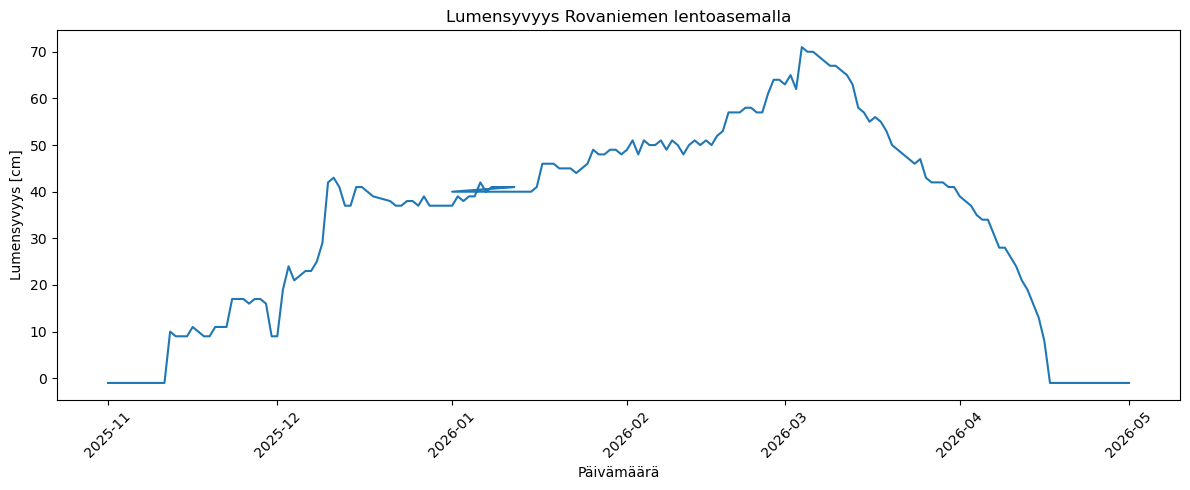

In [93]:
import matplotlib.pyplot as plt

# Plot snow depth over time
plt.figure(figsize=(12, 5))
plt.plot(df["Päivämäärä"], df["Lumensyvyys [cm]"])

plt.title("Lumensyvyys Rovaniemen lentoasemalla")
plt.xlabel("Päivämäärä")
plt.ylabel("Lumensyvyys [cm]")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [94]:
# Check whether the dates are in chronological order
df[["Päivämäärä", "Lumensyvyys [cm]"]].head(20)

,Päivämäärä,Lumensyvyys [cm]
0,2025-11-01,-1
1,2025-11-02,-1
2,2025-11-03,-1
3,2025-11-04,-1
4,2025-11-05,-1
5,2025-11-06,-1
6,2025-11-07,-1
7,2025-11-08,-1
8,2025-11-09,-1
9,2025-11-10,-1


In [95]:
# Check whether the dates are sorted
df["Päivämäärä"].is_monotonic_increasing

False

### Sorting the dates

In [97]:
# Sort the dataset by date
df = df.sort_values("Päivämäärä").reset_index(drop=True)
df["Päivämäärä"].is_monotonic_increasing

True

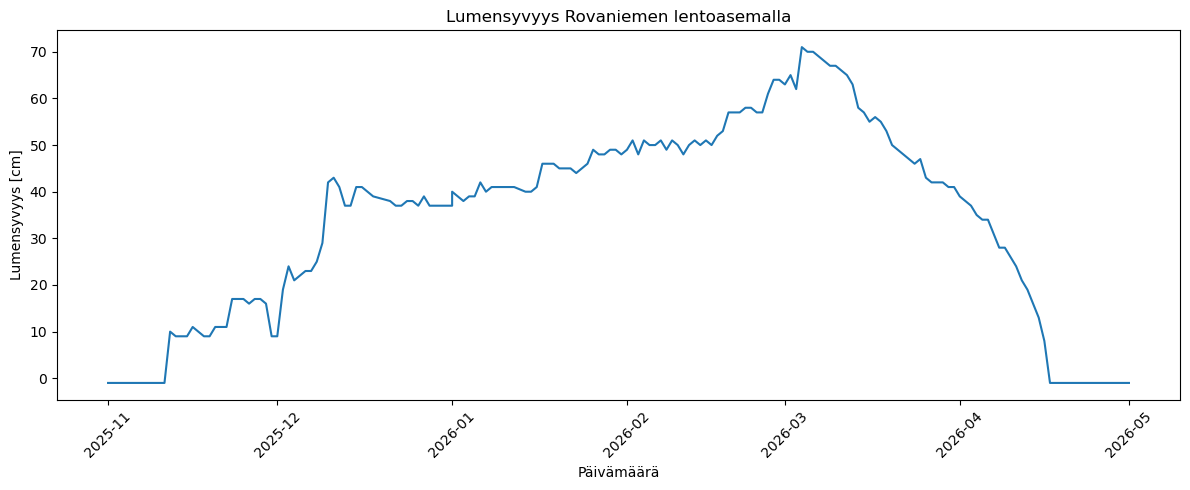

In [98]:
import matplotlib.pyplot as plt

# Plot snow depth over time
plt.figure(figsize=(12, 5))
plt.plot(df["Päivämäärä"], df["Lumensyvyys [cm]"])

plt.title("Lumensyvyys Rovaniemen lentoasemalla")
plt.xlabel("Päivämäärä")
plt.ylabel("Lumensyvyys [cm]")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations

The chart shows changes in snow depth at Rovaniemi Airport from November 2025 to May 2026. 
Snow depth varies throughout the period and also changes over shorter time intervals, which can be seen as rises and falls in the chart.